In [1]:
"""
Phase 8: Perceptual Map — Wired vs The Verge
=============================================
Inputs : data/processed/wired_posts_topics.csv, verge_posts_topics.csv
         outputs/tables/12_wired_micro_influencer_scores.csv,
         outputs/tables/12_verge_micro_influencer_scores.csv
Outputs: outputs/figures/16_perceptual_map.png
         data/processed/perceptual_map_data.json

Axes:
  X = discourse-domain index, share(politics tokens) - share(consumer-tech tokens)
      negative -> politics-leaning, positive -> consumer-tech-leaning
  Y = affective tone, VADER mean compound polarity
Marker size = engagement intensity (mean likes per post, log-scaled).
Both brands plotted as large anchor markers; top 10 micro-influencer
candidates per brand plotted as small markers to show audience composition.
"""
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PROC_DIR = PROJECT_ROOT / "data" / "processed"
TAB_DIR  = PROJECT_ROOT / "outputs" / "tables"
FIG_DIR  = PROJECT_ROOT / "outputs" / "figures"

sns.set_theme(style="whitegrid", context="notebook")
BRAND_COLORS = {"Wired": "#1A1A1A", "The Verge": "#FA4B2A"}

wired_posts  = pd.read_csv(PROC_DIR / "wired_posts_topics.csv")
verge_posts  = pd.read_csv(PROC_DIR / "verge_posts_topics.csv")
wired_scored = pd.read_csv(TAB_DIR / "12_wired_micro_influencer_scores.csv")
verge_scored = pd.read_csv(TAB_DIR / "12_verge_micro_influencer_scores.csv")

# Token sets derived directly from the Phase-6 distinctive-keywords output.
POLITICS_TOKENS = {"trump", "musk", "elon", "doge", "government", "ice",
                   "agency", "security", "treasury", "thiel", "lorenz", "taylor"}
TECH_TOKENS     = {"apple", "google", "xbox", "game", "review", "model",
                   "meta", "openai", "podcast", "carr", "linux", "microsoft"}

def discourse_index(text_series: pd.Series) -> float:
    """Mean per-post (tech_share - politics_share). +1 = pure tech, -1 = pure politics."""
    scores = []
    for txt in text_series.fillna("").astype(str):
        toks = txt.split()
        if not toks:
            continue
        n = len(toks)
        pol = sum(1 for t in toks if t in POLITICS_TOKENS) / n
        tec = sum(1 for t in toks if t in TECH_TOKENS) / n
        scores.append(tec - pol)
    return float(np.mean(scores)) if scores else 0.0

def author_discourse_index(posts: pd.DataFrame, author_did: str) -> float:
    return discourse_index(posts[posts["author_did"] == author_did]["text_clean_no_brand"])

# --- Brand-level coordinates ---
brand_points = []
for brand, posts in [("Wired", wired_posts), ("The Verge", verge_posts)]:
    brand_points.append({
        "brand":          brand,
        "x_discourse":    discourse_index(posts["text_clean_no_brand"]),
        "y_polarity":     float(posts["vader_compound"].mean()),
        "size_engagement": float(posts["like_count"].mean()),
        "n_posts":        len(posts),
    })
brand_df = pd.DataFrame(brand_points)
print("Brand coordinates:")
print(brand_df.to_string(index=False))

# --- Top-10 micro-influencer coordinates ---
def influencer_points(scored: pd.DataFrame, posts: pd.DataFrame, brand: str, top_n: int = 10) -> pd.DataFrame:
    rows = []
    for _, c in scored.head(top_n).iterrows():
        rows.append({
            "brand":           brand,
            "handle":          c["handle"],
            "x_discourse":     author_discourse_index(posts, c["author_did"]),
            "y_polarity":      float(c["mean_compound"]),
            "size_engagement": float(c["mean_likes"]),
            "composite":       float(c["composite_score"]),
        })
    return pd.DataFrame(rows)

inf_df = pd.concat([
    influencer_points(wired_scored, wired_posts, "Wired"),
    influencer_points(verge_scored, verge_posts, "The Verge"),
], ignore_index=True)

print("\nInfluencer coordinates (top 10 per brand):")
print(inf_df.to_string(index=False))

Brand coordinates:
    brand  x_discourse  y_polarity  size_engagement  n_posts
    Wired    -0.020561    0.083611        22.315596     1090
The Verge     0.021607    0.134710         9.602941     1156

Influencer coordinates (top 10 per brand):
    brand                       handle  x_discourse  y_polarity  size_engagement  composite
    Wired       thiccreese.bsky.social     0.000000    0.173400        61.000000   0.604933
    Wired      emilymullin.bsky.social     0.000000    0.360100        41.000000   0.574963
    Wired              ericjgeller.com    -0.040873    0.150817        35.333333   0.456777
    Wired                  skiles.blue    -0.071429    0.123150        64.500000   0.412854
    Wired          epopppp.bsky.social     0.000000    0.746900        16.500000   0.347939
    Wired paranoidfactoid2.bsky.social     0.000000    0.953150         8.000000   0.326070
    Wired     pamspaulding.bsky.social    -0.011905    0.273967        13.333333   0.279441
    Wired    garet

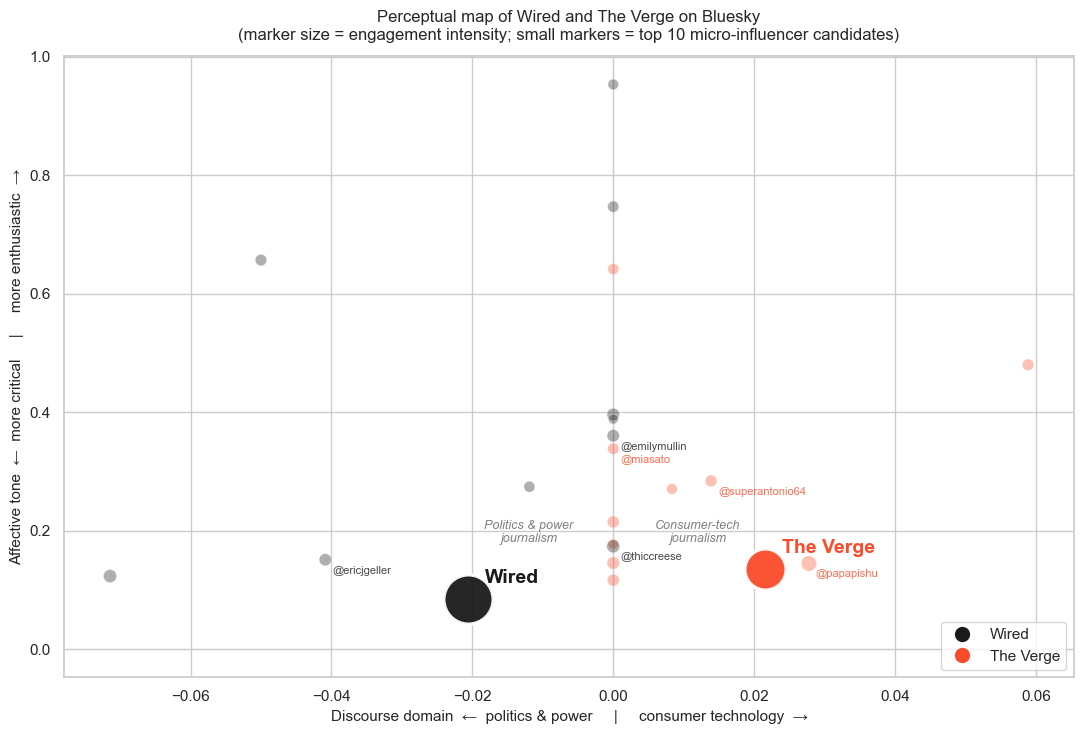

In [2]:
fig, ax = plt.subplots(figsize=(11, 7.5))

# Light background quadrants for interpretive context
ax.axhline(0, color="lightgrey", lw=0.8, zorder=0)
ax.axvline(0, color="lightgrey", lw=0.8, zorder=0)

# Influencer markers (small, semi-transparent)
for brand, g in inf_df.groupby("brand"):
    ax.scatter(g["x_discourse"], g["y_polarity"],
               s=40 + 6 * np.sqrt(g["size_engagement"].clip(lower=0)),
               color=BRAND_COLORS[brand], alpha=0.35,
               edgecolor="white", linewidth=0.5,
               label=f"{brand} influencer candidates", zorder=2)

# Brand anchors (large markers)
for _, row in brand_df.iterrows():
    ax.scatter(row["x_discourse"], row["y_polarity"],
               s=600 + 30 * row["size_engagement"],
               color=BRAND_COLORS[row["brand"]],
               alpha=0.95, edgecolor="white", linewidth=2.5,
               zorder=4)
    ax.annotate(
        row["brand"],
        xy=(row["x_discourse"], row["y_polarity"]),
        xytext=(12, 12), textcoords="offset points",
        fontsize=14, fontweight="bold",
        color=BRAND_COLORS[row["brand"]], zorder=5,
    )

# Label the top-3 influencers per brand to keep the plot legible
for _, row in inf_df.groupby("brand").head(3).iterrows():
    ax.annotate(
        f"@{row['handle'].split('.')[0]}",
        xy=(row["x_discourse"], row["y_polarity"]),
        xytext=(5, -10), textcoords="offset points",
        fontsize=8, color=BRAND_COLORS[row["brand"]], alpha=0.8, zorder=5,
    )

# Quadrant captions — these are interpretive aids, not data
ax.text(-0.012, 0.18, "Politics & power\njournalism", fontsize=9, color="grey",
        ha="center", style="italic")
ax.text( 0.012, 0.18, "Consumer-tech\njournalism",     fontsize=9, color="grey",
        ha="center", style="italic")

ax.set_xlabel("Discourse domain  ←  politics & power     |     consumer technology  →",
              fontsize=11)
ax.set_ylabel("Affective tone  ←  more critical     |     more enthusiastic  →",
              fontsize=11)
ax.set_title("Perceptual map of Wired and The Verge on Bluesky\n"
             "(marker size = engagement intensity; small markers = top 10 micro-influencer candidates)",
             fontsize=12, pad=12)

# Build a clean legend with a single entry per brand
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker="o", color="w", label="Wired",
           markerfacecolor=BRAND_COLORS["Wired"], markersize=12),
    Line2D([0], [0], marker="o", color="w", label="The Verge",
           markerfacecolor=BRAND_COLORS["The Verge"], markersize=12),
]
ax.legend(handles=legend_elements, loc="lower right", frameon=True)

plt.tight_layout()
plt.savefig(FIG_DIR / "16_perceptual_map.png", dpi=180, bbox_inches="tight")
plt.show()

In [3]:
perceptual_data = {
    "axes": {
        "x_definition": ("Discourse-domain index = mean per-post (tech_token_share - politics_token_share). "
                         "Negative -> politics & power; positive -> consumer technology."),
        "y_definition": "Affective tone = mean VADER compound polarity per brand.",
        "size_definition": "Engagement intensity = mean likes per post.",
    },
    "axis_token_sets": {
        "politics_power":      sorted(POLITICS_TOKENS),
        "consumer_technology": sorted(TECH_TOKENS),
    },
    "brand_points":      brand_df.to_dict("records"),
    "influencer_points": inf_df.to_dict("records"),
    "interpretation": [
        "Wired sits in the lower-left quadrant: politics-and-power journalism with a critical, slightly negative tone, but with high engagement intensity driven by a viral right-tail of political reporting (e.g. DOGE, Trump-Musk coverage).",
        "The Verge sits in the upper-right quadrant: consumer-technology journalism with a positive tone driven by product reviews and feature coverage (Apple, Google, Xbox, openAI), with steadier but lower per-post engagement.",
        "The two brands occupy genuinely distinct positions on the map — the X-axis separation is large and based directly on observed vocabulary; the Y-axis separation is smaller but consistent across topic, post-type, and sentiment cuts.",
        "Influencer candidates cluster tightly around each brand's anchor, validating that the recommended micro-influencers reflect the brand's discourse position rather than sitting in the opposite quadrant.",
    ],
}
with open(PROC_DIR / "perceptual_map_data.json", "w") as f:
    json.dump(perceptual_data, f, indent=2, default=str)

print("Saved data/processed/perceptual_map_data.json")

Saved data/processed/perceptual_map_data.json
